In [1]:
import torch as th
import numpy as np
import torch.nn as nn
import torch.optim as opt
import matplotlib.pyplot as plt
import scipy.io as sio
import time
import os
import pandas as pd
import scipy.signal as scs
from tqdm import tqdm
import seaborn as sns

import sys
sys.path.append('..')

import soft_tex.common.aux_plot
from soft_tex.common.aux_data import get_dataset_dict, exponential_moving_average

data_dir_path = '../data/SoftTex/'

### Load datasets (pressure, resistance, position)

In [2]:
dataset_names = ['dataset_res_sens_pos_1.mat', 
                 'dataset_res_sens_pos_2.mat', 
                 'dataset_res_sens_pos_3.mat']

dataset_dict = get_dataset_dict(data_dir_path=data_dir_path, dataset_names=dataset_names)

print(dataset_dict.keys())
print(dataset_dict[list(dataset_dict.keys())[0]].keys())

# load pressure datasets
pressure_dataset_names = ['dataset_act_sens_pos_1.mat', 
                          'dataset_act_sens_pos_2.mat', 
                          'dataset_act_sens_pos_3.mat']

for dataset_name, pressure_dataset_name in zip(dataset_names, pressure_dataset_names):
    dataset = sio.loadmat(data_dir_path + pressure_dataset_name)['Dataset']
    pressures = dataset[:, [0,1,2]]

    dataset_dict[dataset_name]['pressure'] = pressures

print(dataset_dict.keys())
print(dataset_dict[list(dataset_dict.keys())[0]].keys())

dict_keys(['dataset_res_sens_pos_1.mat', 'dataset_res_sens_pos_2.mat', 'dataset_res_sens_pos_3.mat'])
dict_keys(['sensor_voltage', 'sensor_resistance', 'tip_position'])
dict_keys(['dataset_res_sens_pos_1.mat', 'dataset_res_sens_pos_2.mat', 'dataset_res_sens_pos_3.mat'])
dict_keys(['sensor_voltage', 'sensor_resistance', 'tip_position', 'pressure'])


### Analyze datasets

In [62]:
# Dataset infos
sampling_frequency = 50 # Hz
delta_t = 1.0 / sampling_frequency # s

for dataset_name in dataset_names:
    sensor_voltage = dataset_dict[dataset_name]['sensor_voltage']
    tip_position = dataset_dict[dataset_name]['tip_position']
    
    print(dataset_name)
    n_samples = sensor_voltage.shape[0]
    total_time = n_samples / sampling_frequency
    print("n_samples:", n_samples)
    print("total time:", total_time, "s")

    # Tip ranges
    tip_min = np.min(tip_position, axis=0)
    tip_max = np.max(tip_position, axis=0)
    tip_range = tip_max - tip_min
    print("tip ranges: (%.0f, %.0f, %.0f) mm" % (tip_range[0], tip_range[1], tip_range[2]))

    # Tip velocities
    tip_velocities = np.diff(a=tip_position, n=1, axis=0, prepend=tip_position[0].reshape(1,-1)) / delta_t
    tip_velocity_magnitudes = np.linalg.norm(tip_velocities, axis=1)
    
    print("average tip velocity: %.0f mm/s pm %.0f mm/s" % (np.mean(tip_velocity_magnitudes), np.std(tip_velocity_magnitudes)))
    print("maximum tip velocity: %.0f mm/s" % np.max(tip_velocity_magnitudes))

    print()

dataset_res_sens_pos_1.mat
n_samples: 10801
total time: 216.02 s
tip ranges: (80, 67, 37) mm
average tip velocity: 17 mm/s pm 22 mm/s
maximum tip velocity: 202 mm/s

dataset_res_sens_pos_2.mat
n_samples: 5401
total time: 108.02 s
tip ranges: (76, 67, 39) mm
average tip velocity: 28 mm/s pm 30 mm/s
maximum tip velocity: 198 mm/s

dataset_res_sens_pos_3.mat
n_samples: 16201
total time: 324.02 s
tip ranges: (78, 70, 41) mm
average tip velocity: 13 mm/s pm 19 mm/s
maximum tip velocity: 339 mm/s



### Plot input pressure and resistance

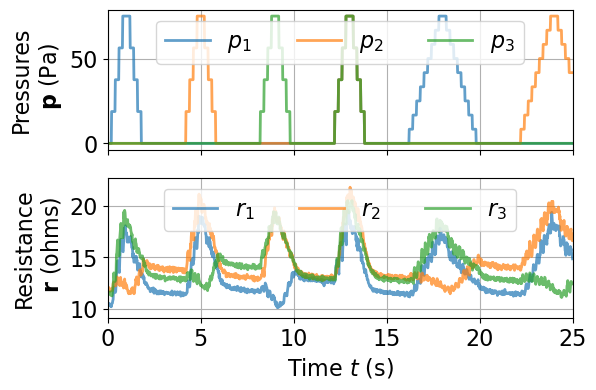

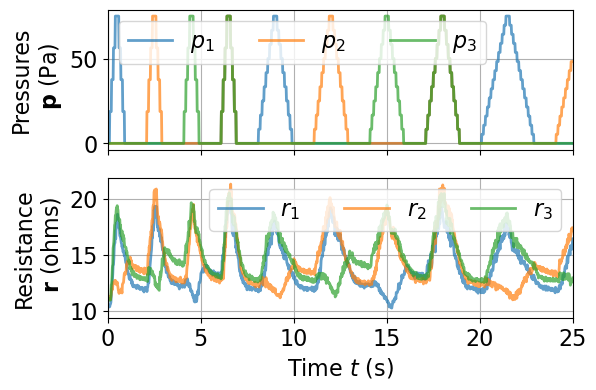

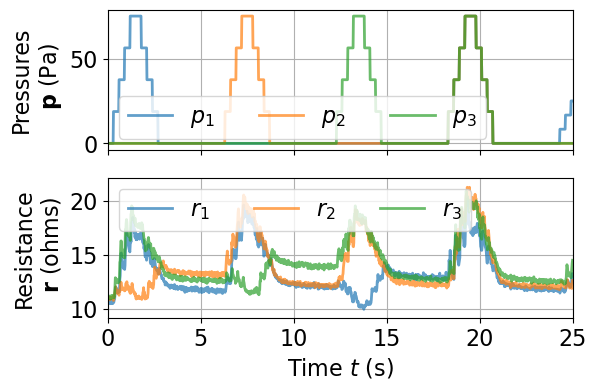

In [61]:
sampling_frequency = 50 # Hz

for i in range(3):
    # create a figure with 2 subplots
    fig, axs = plt.subplots(ncols=1, nrows=2, sharex=True, figsize=(6,4))

    # get actuator pressures and sensor resistance
    pressures = dataset_dict['dataset_res_sens_pos_%d.mat' % (i+1)]['pressure']
    resistance = dataset_dict['dataset_res_sens_pos_%d.mat' % (i+1)]['sensor_resistance']
    
    # make the time axis
    n_samples = pressures.shape[0]
    total_time = n_samples / sampling_frequency
    time_axis = np.linspace(0, total_time, n_samples)

    # plot actuator pressures
    lines_p = axs[0].plot(time_axis, pressures, linewidth=2, alpha=0.7)
    axs[0].grid()
    axs[0].set_ylabel('Pressures\n $\\mathbf{p}$ (Pa)')
    axs[0].legend(handles=lines_p, labels=['$p_1$', '$p_2$', '$p_3$'], ncols=3, loc='best')
    
    # Plot sensor resistance
    lines_r = axs[1].plot(time_axis, resistance, linewidth=2, alpha=0.7)
    axs[1].grid()
    axs[1].set_xlabel('Time $t$ (s)')
    axs[1].set_ylabel('Resistance\n $\\mathbf{r}$ (ohms)')
    axs[1].legend(handles=lines_r, labels=['$r_1$', '$r_2$', '$r_3$'], ncols=3, loc='best')

    # do not show the whole time series for clarity
    plt.xlim([0,25])
    plt.show()

### Check data distributions

In [63]:
import seaborn as sns

data_dir_path = '../data/SoftTex/'
dataset_names = ['dataset_res_sens_pos_1.mat', 'dataset_res_sens_pos_2.mat', 'dataset_res_sens_pos_3.mat']

dataset_dict = get_dataset_dict(data_dir_path=data_dir_path, dataset_names=dataset_names)

# Concatenate pressure dataset
pressure_dataset_names = ['dataset_act_sens_pos_1.mat', 
                          'dataset_act_sens_pos_2.mat', 
                          'dataset_act_sens_pos_3.mat']

for dataset_name, pressure_dataset_name in zip(dataset_names, pressure_dataset_names):
    dataset = sio.loadmat(data_dir_path + pressure_dataset_name)['Dataset']
    pressures = dataset[:, [0,1,2]]

    dataset_dict[dataset_name]['pressure'] = pressures


TR_idx, VL_idx, TS_idx = 3, 1, 2

tr_pressure = dataset_dict['dataset_res_sens_pos_%d.mat' % TR_idx]['pressure']
tr_sensor = dataset_dict['dataset_res_sens_pos_%d.mat' % TR_idx]['sensor_resistance']
tr_tip_position = dataset_dict['dataset_res_sens_pos_%d.mat' % TR_idx]['tip_position']

vl_pressure = dataset_dict['dataset_res_sens_pos_%d.mat' % VL_idx]['pressure']
vl_sensor = dataset_dict['dataset_res_sens_pos_%d.mat' % VL_idx]['sensor_resistance']
vl_tip_position = dataset_dict['dataset_res_sens_pos_%d.mat' % VL_idx]['tip_position']

ts_pressure = dataset_dict['dataset_res_sens_pos_%d.mat' % TS_idx]['pressure']
ts_sensor = dataset_dict['dataset_res_sens_pos_%d.mat' % TS_idx]['sensor_resistance']
ts_tip_position = dataset_dict['dataset_res_sens_pos_%d.mat' % TS_idx]['tip_position']

In [65]:
name_to_curve_color = {'Training set': sns.palettes.SEABORN_PALETTES['dark'][2],
                       'Validation set': sns.palettes.SEABORN_PALETTES['dark'][0],
                       'Test set': sns.palettes.SEABORN_PALETTES['dark'][1]}

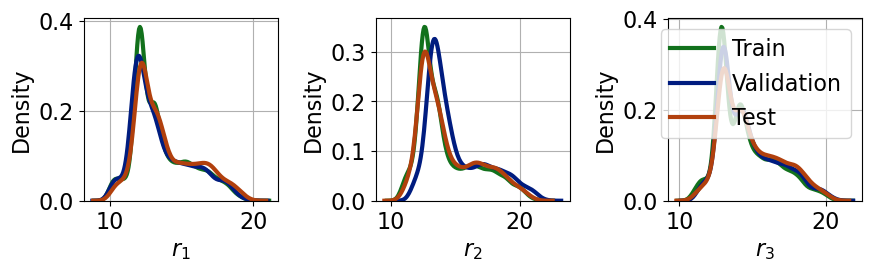

In [ ]:
# distribution of sensor resistance for each axes and for each dataset
fig, axes = plt.subplots(nrows=1,ncols=3,figsize=(9,3))

sns.kdeplot(ax=axes[0], data=tr_sensor[:,0], color=name_to_curve_color['Training set'], linewidth=3)
sns.kdeplot(ax=axes[0], data=vl_sensor[:,0], color=name_to_curve_color['Validation set'], linewidth=3)
sns.kdeplot(ax=axes[0], data=ts_sensor[:,0], color=name_to_curve_color['Test set'], linewidth=3)

sns.kdeplot(ax=axes[1], data=tr_sensor[:,1], color=name_to_curve_color['Training set'], linewidth=3, label='Train')
sns.kdeplot(ax=axes[1], data=vl_sensor[:,1], color=name_to_curve_color['Validation set'], linewidth=3, label='Validation')
sns.kdeplot(ax=axes[1], data=ts_sensor[:,1], color=name_to_curve_color['Test set'], linewidth=3, label='Test')

sns.kdeplot(ax=axes[2], data=tr_sensor[:,2], color=name_to_curve_color['Training set'], linewidth=3, label='Train')
sns.kdeplot(ax=axes[2], data=vl_sensor[:,2], color=name_to_curve_color['Validation set'], linewidth=3, label='Validation')
sns.kdeplot(ax=axes[2], data=ts_sensor[:,2], color=name_to_curve_color['Test set'], linewidth=3, label='Test')

axes[2].legend(loc='best')

axes[0].grid()
axes[1].grid()
axes[2].grid()

axes[0].set_xlabel('$r_1$')
axes[1].set_xlabel('$r_2$')
axes[2].set_xlabel('$r_3$')

plt.tight_layout()

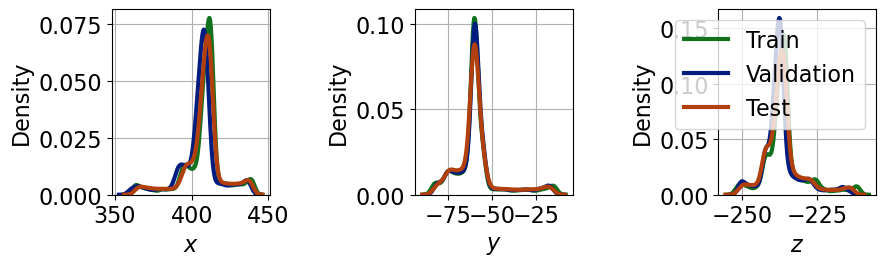

In [89]:
# distribution of tip positions on each axes for each dataset
fig, axes = plt.subplots(nrows=1,ncols=3,figsize=(9,3))

sns.kdeplot(ax=axes[0], data=tr_tip_position[:,0], color=name_to_curve_color['Training set'], linewidth=3, label='train')
sns.kdeplot(ax=axes[0], data=vl_tip_position[:,0], color=name_to_curve_color['Validation set'], linewidth=3, label='validation')
sns.kdeplot(ax=axes[0], data=ts_tip_position[:,0], color=name_to_curve_color['Test set'], linewidth=3, label='test')

sns.kdeplot(ax=axes[1], data=tr_tip_position[:,1], color=name_to_curve_color['Training set'], linewidth=3, label='Train')
sns.kdeplot(ax=axes[1], data=vl_tip_position[:,1], color=name_to_curve_color['Validation set'], linewidth=3, label='Validation')
sns.kdeplot(ax=axes[1], data=ts_tip_position[:,1], color=name_to_curve_color['Test set'], linewidth=3, label='Test')

sns.kdeplot(ax=axes[2], data=tr_tip_position[:,2], color=name_to_curve_color['Training set'], linewidth=3, label='Train')
sns.kdeplot(ax=axes[2], data=vl_tip_position[:,2], color=name_to_curve_color['Validation set'], linewidth=3, label='Validation')
sns.kdeplot(ax=axes[2], data=ts_tip_position[:,2], color=name_to_curve_color['Test set'], linewidth=3, label='Test')

axes[2].legend(loc='best')

axes[0].grid()
axes[1].grid()
axes[2].grid()

axes[0].set_xlabel('$x$')
axes[1].set_xlabel('$y$')
axes[2].set_xlabel('$z$')

plt.tight_layout()

### Check exponential moving average

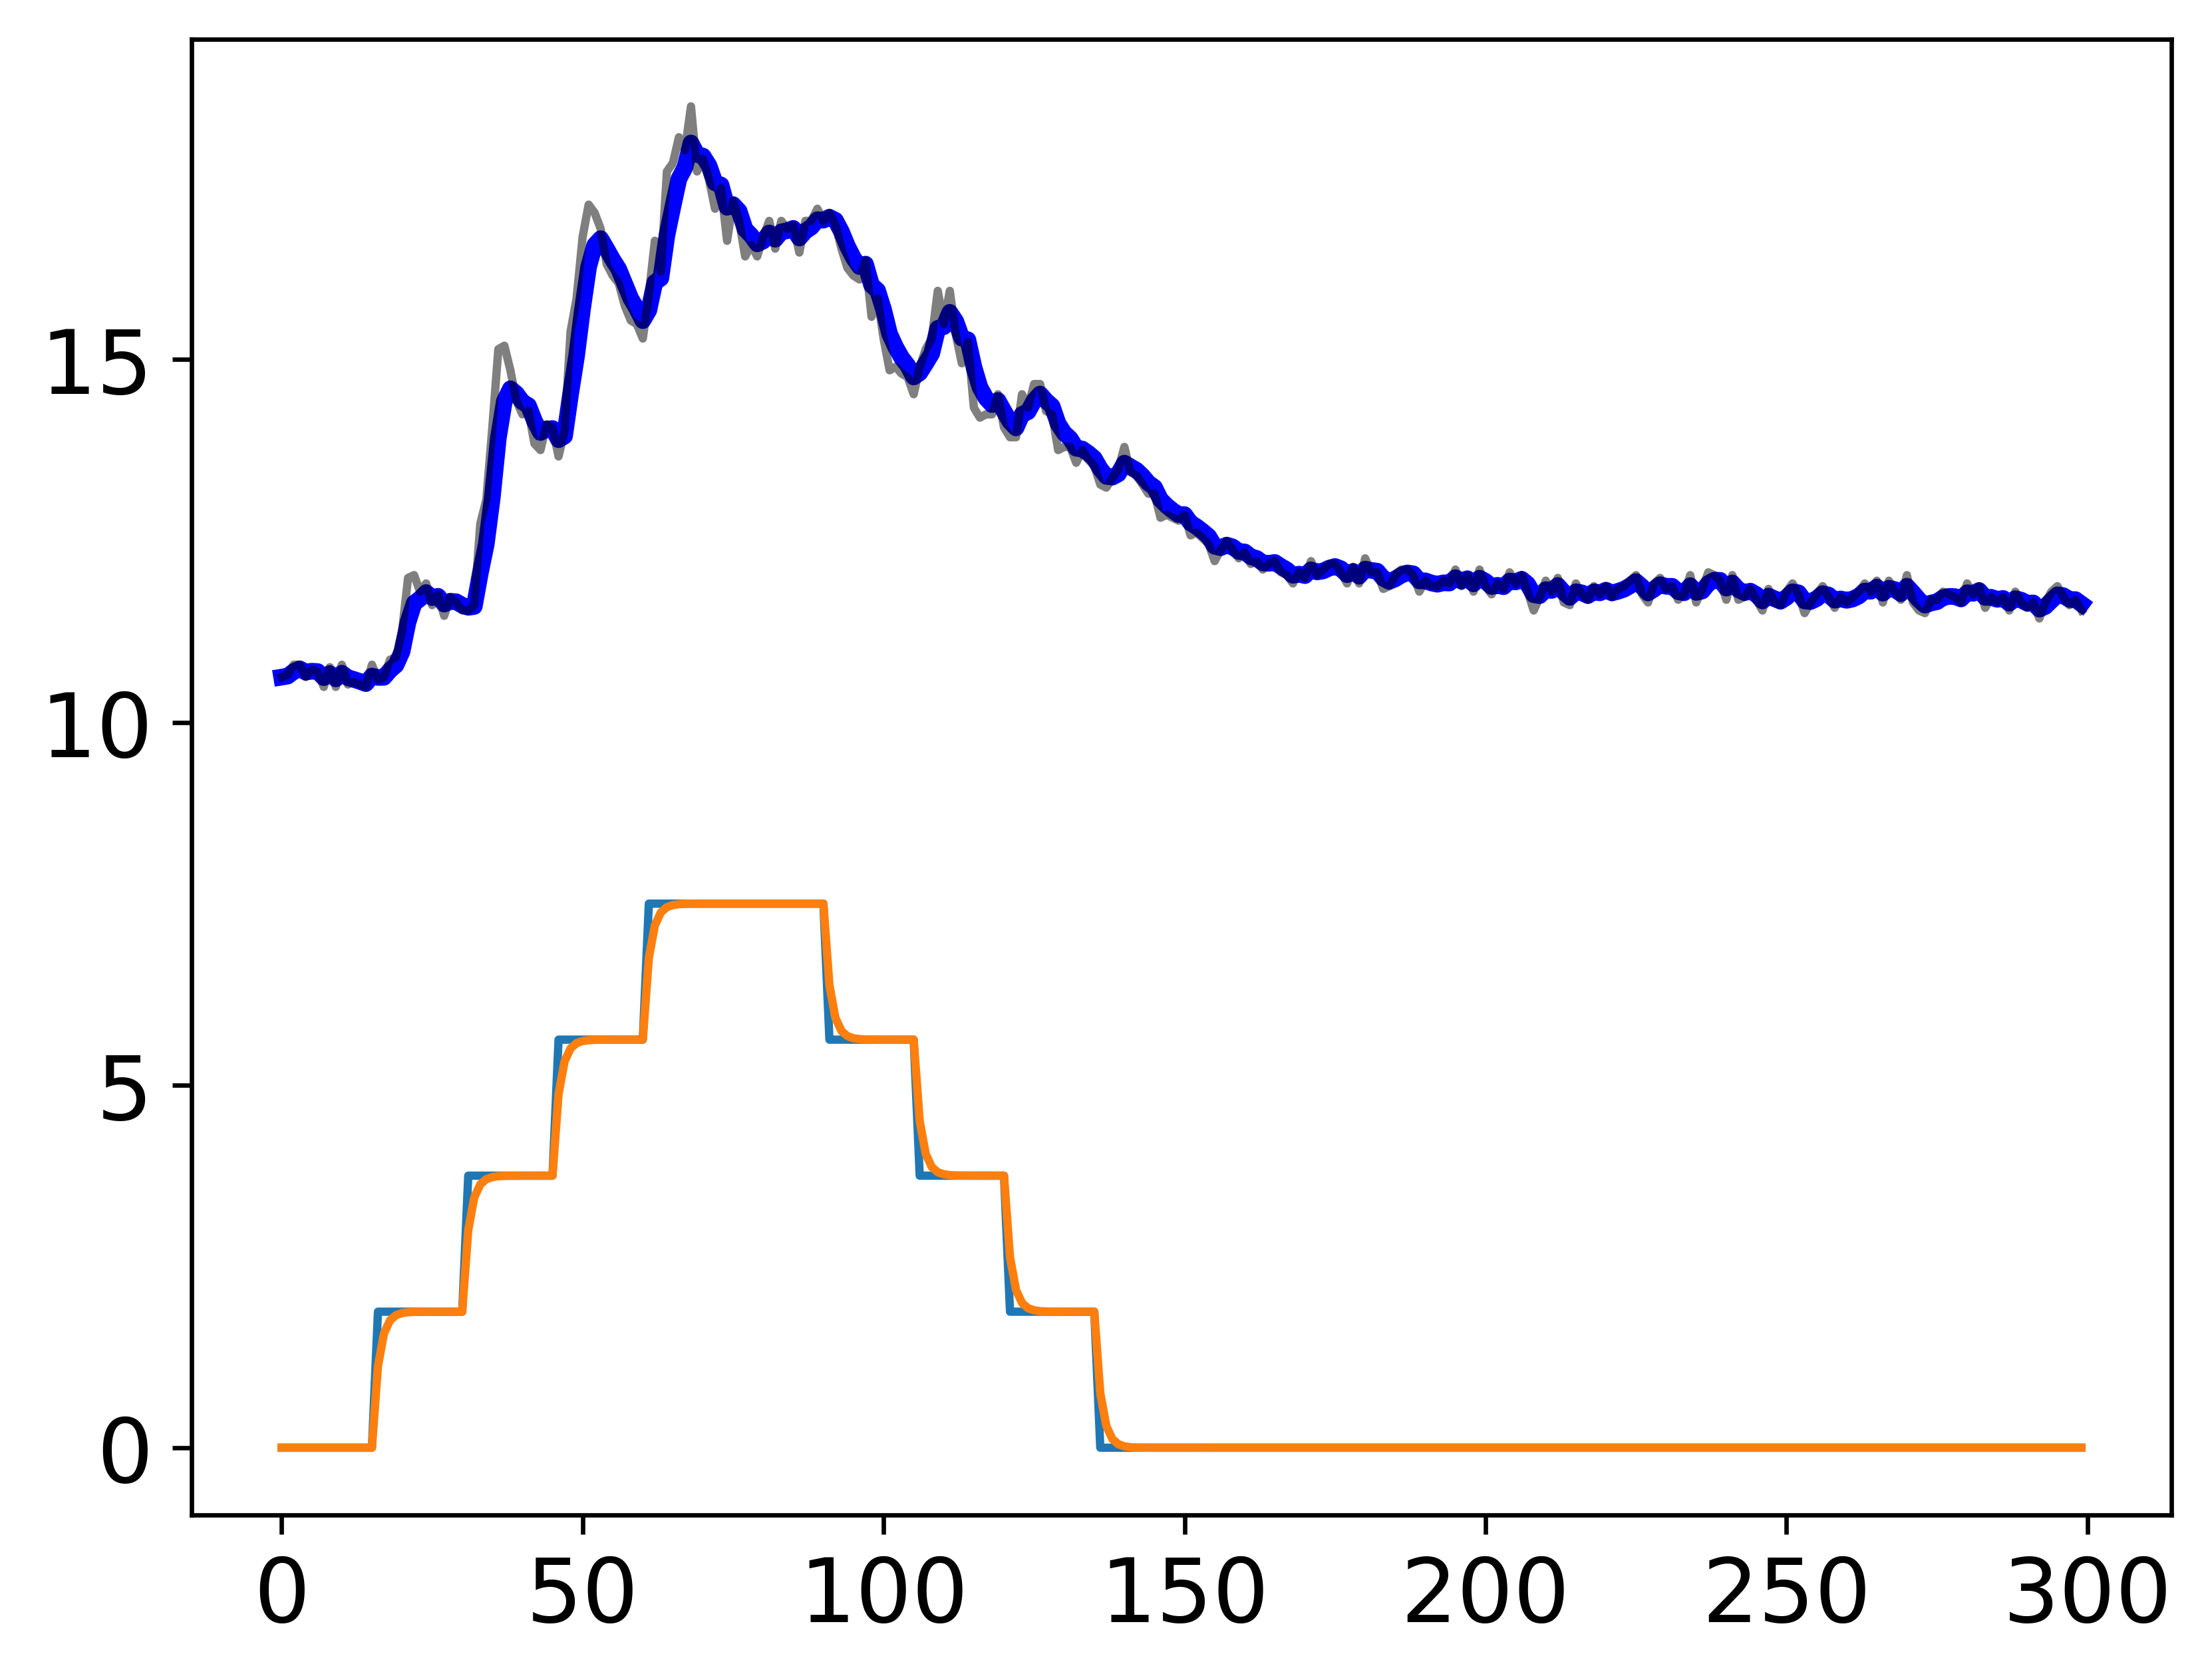

In [ ]:
s_tr_sensor = exponential_moving_average(tr_sensor, alpha=0.4)
s_vl_sensor = exponential_moving_average(vl_sensor, alpha=0.4)
s_tr_pressure = exponential_moving_average(tr_pressure, alpha=0.6)
s_tr_pressure = exponential_moving_average(tr_pressure, alpha=np.array([0.6,0.6,0.6]))

plt.figure(dpi=600)
plt.plot(s_tr_sensor[:300,0],linewidth=3, color='blue')
plt.plot(tr_sensor[:300,0], color='black', alpha=0.5)
plt.plot(tr_pressure[:300,0]/10)
plt.plot(s_tr_pressure[:300,0]/10)
#plt.plot(s_vl_sensor[:200,0],linewidth=3, color='orange')
#plt.plot(vl_sensor[:200,0], color='black', alpha=0.5)

## Push and Pull Force Tests

In [8]:
pressures = [50, 100, 150, 200] # kPa

# Pulling datasets
pull_50_names = [
    data_dir_path + 'force_tests/pull_01_stiff-flop_1_1.csv',
    data_dir_path + 'force_tests/pull_01_stiff-flop_2_1.csv',
    data_dir_path + 'force_tests/pull_01_stiff-flop_3_1.csv']

pull_100_names = [
    data_dir_path + 'force_tests/pull_01_stiff-flop_4_1.csv',
    data_dir_path + 'force_tests/pull_01_stiff-flop_5_1.csv',
    data_dir_path + 'force_tests/pull_01_stiff-flop_6_1.csv']

pull_150_names = [
    data_dir_path + 'force_tests/pull_01_stiff-flop_7_1.csv',
    data_dir_path + 'force_tests/pull_01_stiff-flop_8_1.csv',
    data_dir_path + 'force_tests/pull_01_stiff-flop_9_1.csv']

pull_200_names = [
    data_dir_path + 'force_tests/pull_01_stiff-flop_10_1.csv',
    data_dir_path + 'force_tests/pull_01_stiff-flop_11_1.csv',
    data_dir_path + 'force_tests/pull_01_stiff-flop_12_1.csv']

# Pushing datasets
push_50_names = [data_dir_path + 'force_tests/push01_stiff-flop_1_1.csv',
                 data_dir_path + 'force_tests/push01_stiff-flop_2_1.csv',
                 data_dir_path + 'force_tests/push01_stiff-flop_3_1.csv',
                 ]

push_100_names = [data_dir_path + 'force_tests/push01_stiff-flop_4_1.csv',
                 data_dir_path + 'force_tests/push01_stiff-flop_5_1.csv',
                 data_dir_path + 'force_tests/push01_stiff-flop_6_1.csv']

push_150_names = [data_dir_path + 'force_tests/push01_stiff-flop_7_1.csv',
                 data_dir_path + 'force_tests/push01_stiff-flop_8_1.csv',
                 data_dir_path + 'force_tests/push01_stiff-flop_9_1.csv']

push_200_names = [data_dir_path + 'force_tests/push01_stiff-flop_10_1.csv',
                 data_dir_path + 'force_tests/push01_stiff-flop_11_1.csv',
                 data_dir_path + 'force_tests/push01_stiff-flop_12_1.csv']

In [9]:
# Pull dataframes
pull_50_dfs = [pd.read_csv(name).iloc[1:] for name in pull_50_names] # remove first row
pull_100_dfs = [pd.read_csv(name).iloc[1:] for name in pull_100_names] # remove first row
pull_150_dfs = [pd.read_csv(name).iloc[1:] for name in pull_150_names] # remove first row
pull_200_dfs = [pd.read_csv(name).iloc[1:] for name in pull_200_names] # remove first row

# Push dataframes
push_50_dfs = [pd.read_csv(name).iloc[1:] for name in push_50_names] # remove first row
push_100_dfs = [pd.read_csv(name).iloc[1:] for name in push_100_names] # remove first row
push_150_dfs = [pd.read_csv(name).iloc[1:] for name in push_150_names] # remove first row
push_200_dfs = [pd.read_csv(name).iloc[1:] for name in push_200_names] # remove first row

In [10]:
# Extract maximum force from the time series of each trial, then average the maximum values

# Pull
max_pull_forces_50 = [df['Force'].to_numpy(dtype=np.float32).min() for df in pull_50_dfs]
max_pull_forces_100 = [df['Force'].to_numpy(dtype=np.float32).min() for df in pull_100_dfs]
max_pull_forces_150 = [df['Force'].to_numpy(dtype=np.float32).min() for df in pull_150_dfs]
max_pull_forces_200 = [df['Force'].to_numpy(dtype=np.float32).min() for df in pull_200_dfs]

mean_pull_forces = [np.abs(np.mean(max_pull_forces_50)),
                    np.abs(np.mean(max_pull_forces_100)),
                    np.abs(np.mean(max_pull_forces_150)),
                    np.abs(np.mean(max_pull_forces_200))]
                    

std_pull_forces = [np.std(max_pull_forces_50), 
                   np.std(max_pull_forces_100),
                   np.std(max_pull_forces_150),
                   np.std(max_pull_forces_200)]

# Push
max_push_forces_50 = [df['Force'].to_numpy(dtype=np.float32).max() for df in push_50_dfs]
max_push_forces_100 = [df['Force'].to_numpy(dtype=np.float32).max() for df in push_100_dfs]
max_push_forces_150 = [df['Force'].to_numpy(dtype=np.float32).max() for df in push_150_dfs]
max_push_forces_200 = [df['Force'].to_numpy(dtype=np.float32).max() for df in push_200_dfs]

mean_push_forces = [np.abs(np.mean(max_push_forces_50)),
                    np.abs(np.mean(max_push_forces_100)),
                    np.abs(np.mean(max_push_forces_150)),
                    np.abs(np.mean(max_push_forces_200))]
                    
std_push_forces = [np.std(max_push_forces_50), 
                   np.std(max_push_forces_100),
                   np.std(max_push_forces_150),
                   np.std(max_push_forces_200)]

# TODO: flippa ora ma fixa
mean_push_forces = np.flip(mean_push_forces)
std_push_forces = np.flip(std_push_forces)

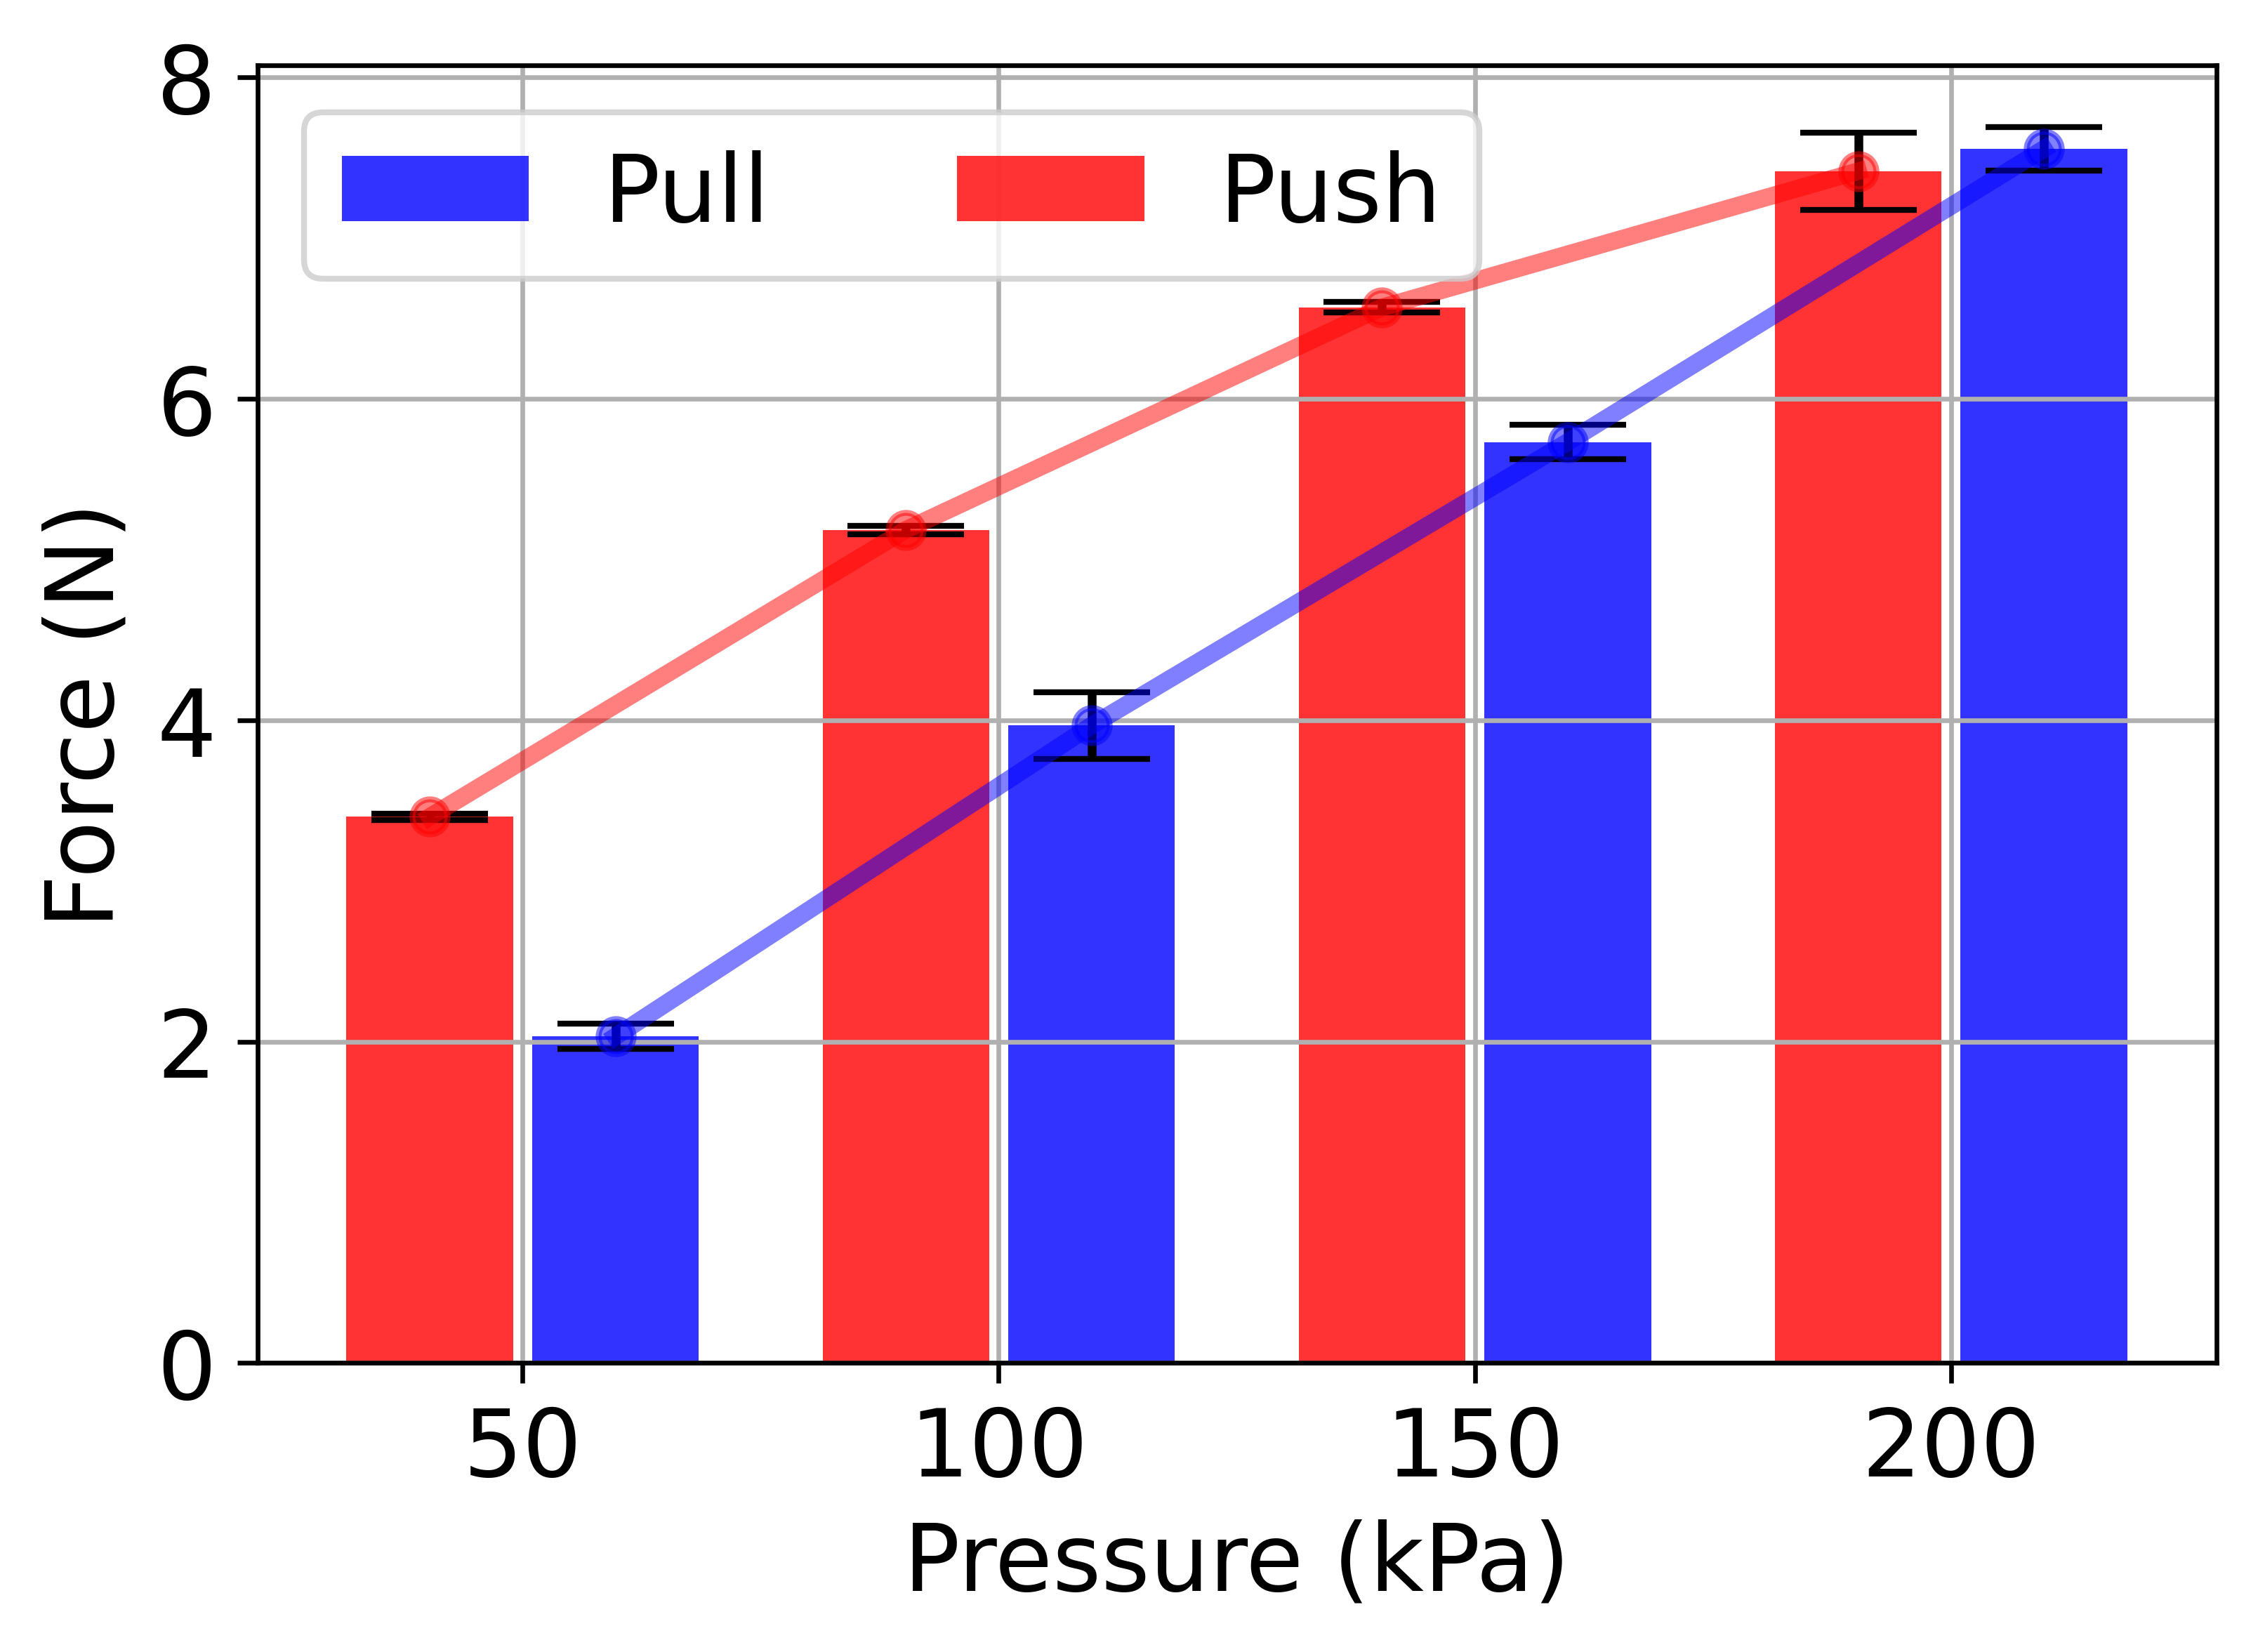

In [11]:
bar_w = 0.35
x_pull = np.arange(len(pressures)) + bar_w/2 + 0.02
x_push = np.arange(len(pressures)) - bar_w/2 - 0.02

fig = plt.figure(figsize=(6,4), dpi=600)
plt.bar(x=x_pull, height=mean_pull_forces, yerr=std_pull_forces, width=bar_w, label='Pull',
        color='blue', ecolor='black', linewidth=3, capsize=10, alpha=0.8)
plt.plot(x_pull, mean_pull_forces, 'o-', linewidth=3, alpha=0.5, color='blue')

# TODO fix flip
plt.bar(x=x_push, height=mean_push_forces, yerr=std_push_forces, width=bar_w, label='Push',
        color='red', ecolor='black', linewidth=3, capsize=10, alpha=0.8)
plt.plot(x_push, mean_push_forces, 'o-', linewidth=3, alpha=0.5, color='red')

plt.xticks([0,1,2,3], pressures)
plt.ylabel('Force (N)')
plt.xlabel('Pressure (kPa)')
plt.grid()
plt.legend(loc='best', ncols=2)
#fig.savefig('../figures/textile_stiff-flop_force_tests.pdf', bbox_inches='tight')
#fig.savefig('../figures/textile_stiff-flop_force_tests.png', bbox_inches='tight')
plt.show()

In [20]:
for i, p in enumerate(pressures):
    print("Pressure %d (kPa) - Pull force: %.2f +- %.2f (N)" % (p, mean_pull_forces[i], std_pull_forces[i]))

print()

for i, p in enumerate(pressures):
    print("Pressure %d (kPa) - Push force: %.2f +- %.2f (N)" % (p, mean_push_forces[i], std_push_forces[i]))

Pressure 50 (kPa) - Pull force: 2.03 +- 0.08 (N)
Pressure 100 (kPa) - Pull force: 3.97 +- 0.21 (N)
Pressure 150 (kPa) - Pull force: 5.73 +- 0.11 (N)
Pressure 200 (kPa) - Pull force: 7.55 +- 0.13 (N)

Pressure 50 (kPa) - Push force: 3.40 +- 0.02 (N)
Pressure 100 (kPa) - Push force: 5.18 +- 0.03 (N)
Pressure 150 (kPa) - Push force: 6.57 +- 0.03 (N)
Pressure 200 (kPa) - Push force: 7.42 +- 0.24 (N)


## Workspace Characterization

In [7]:
ws_data_df = pd.read_excel(data_dir_path + 'workspace_characterization/workspace.xlsx')
ws_data_df.columns

Index(['p [KPa]', 'dl1 [mm]', 'dl2 [mm]', 'dl3  [mm]', 'edl1 [mm]',
       'edl2 [mm]', 'edl3  [mm]', 'thetacl1 [°]', 'thetacl2 [°]',
       'thetacl3 [°]', 'dtheta1 [°]', 'dtheta2 [°]', 'dtheta3 [°]',
       'theta_acl1 [°]', 'thetacl2 [°].1', 'thetacl3 [°].1', 'dtheta1 [°].1',
       'dtheta2 [°].1', 'dtheta3 [°].1'],
      dtype='object')

In [8]:
pressures = ws_data_df['p [KPa]'].to_numpy()

delta_ls = ws_data_df[['dl1 [mm]', 'dl2 [mm]', 'dl3  [mm]']].to_numpy()
error_delta_ls = ws_data_df[['edl1 [mm]', 'edl2 [mm]', 'edl3  [mm]']].to_numpy()

theta_1 = ws_data_df[['thetacl1 [°]', 'thetacl2 [°]', 'thetacl3 [°]']].to_numpy()
error_theta_1 = ws_data_df[['dtheta1 [°]', 'dtheta2 [°]', 'dtheta3 [°]']].to_numpy()

theta_2 = ws_data_df[['theta_acl1 [°]', 'thetacl2 [°].1', 'thetacl3 [°].1']].to_numpy()
error_theta_2 = ws_data_df[['dtheta1 [°].1', 'dtheta2 [°].1', 'dtheta3 [°].1']].to_numpy()

pressures.shape, delta_ls.shape, error_delta_ls.shape

((11,), (11, 3), (11, 3))

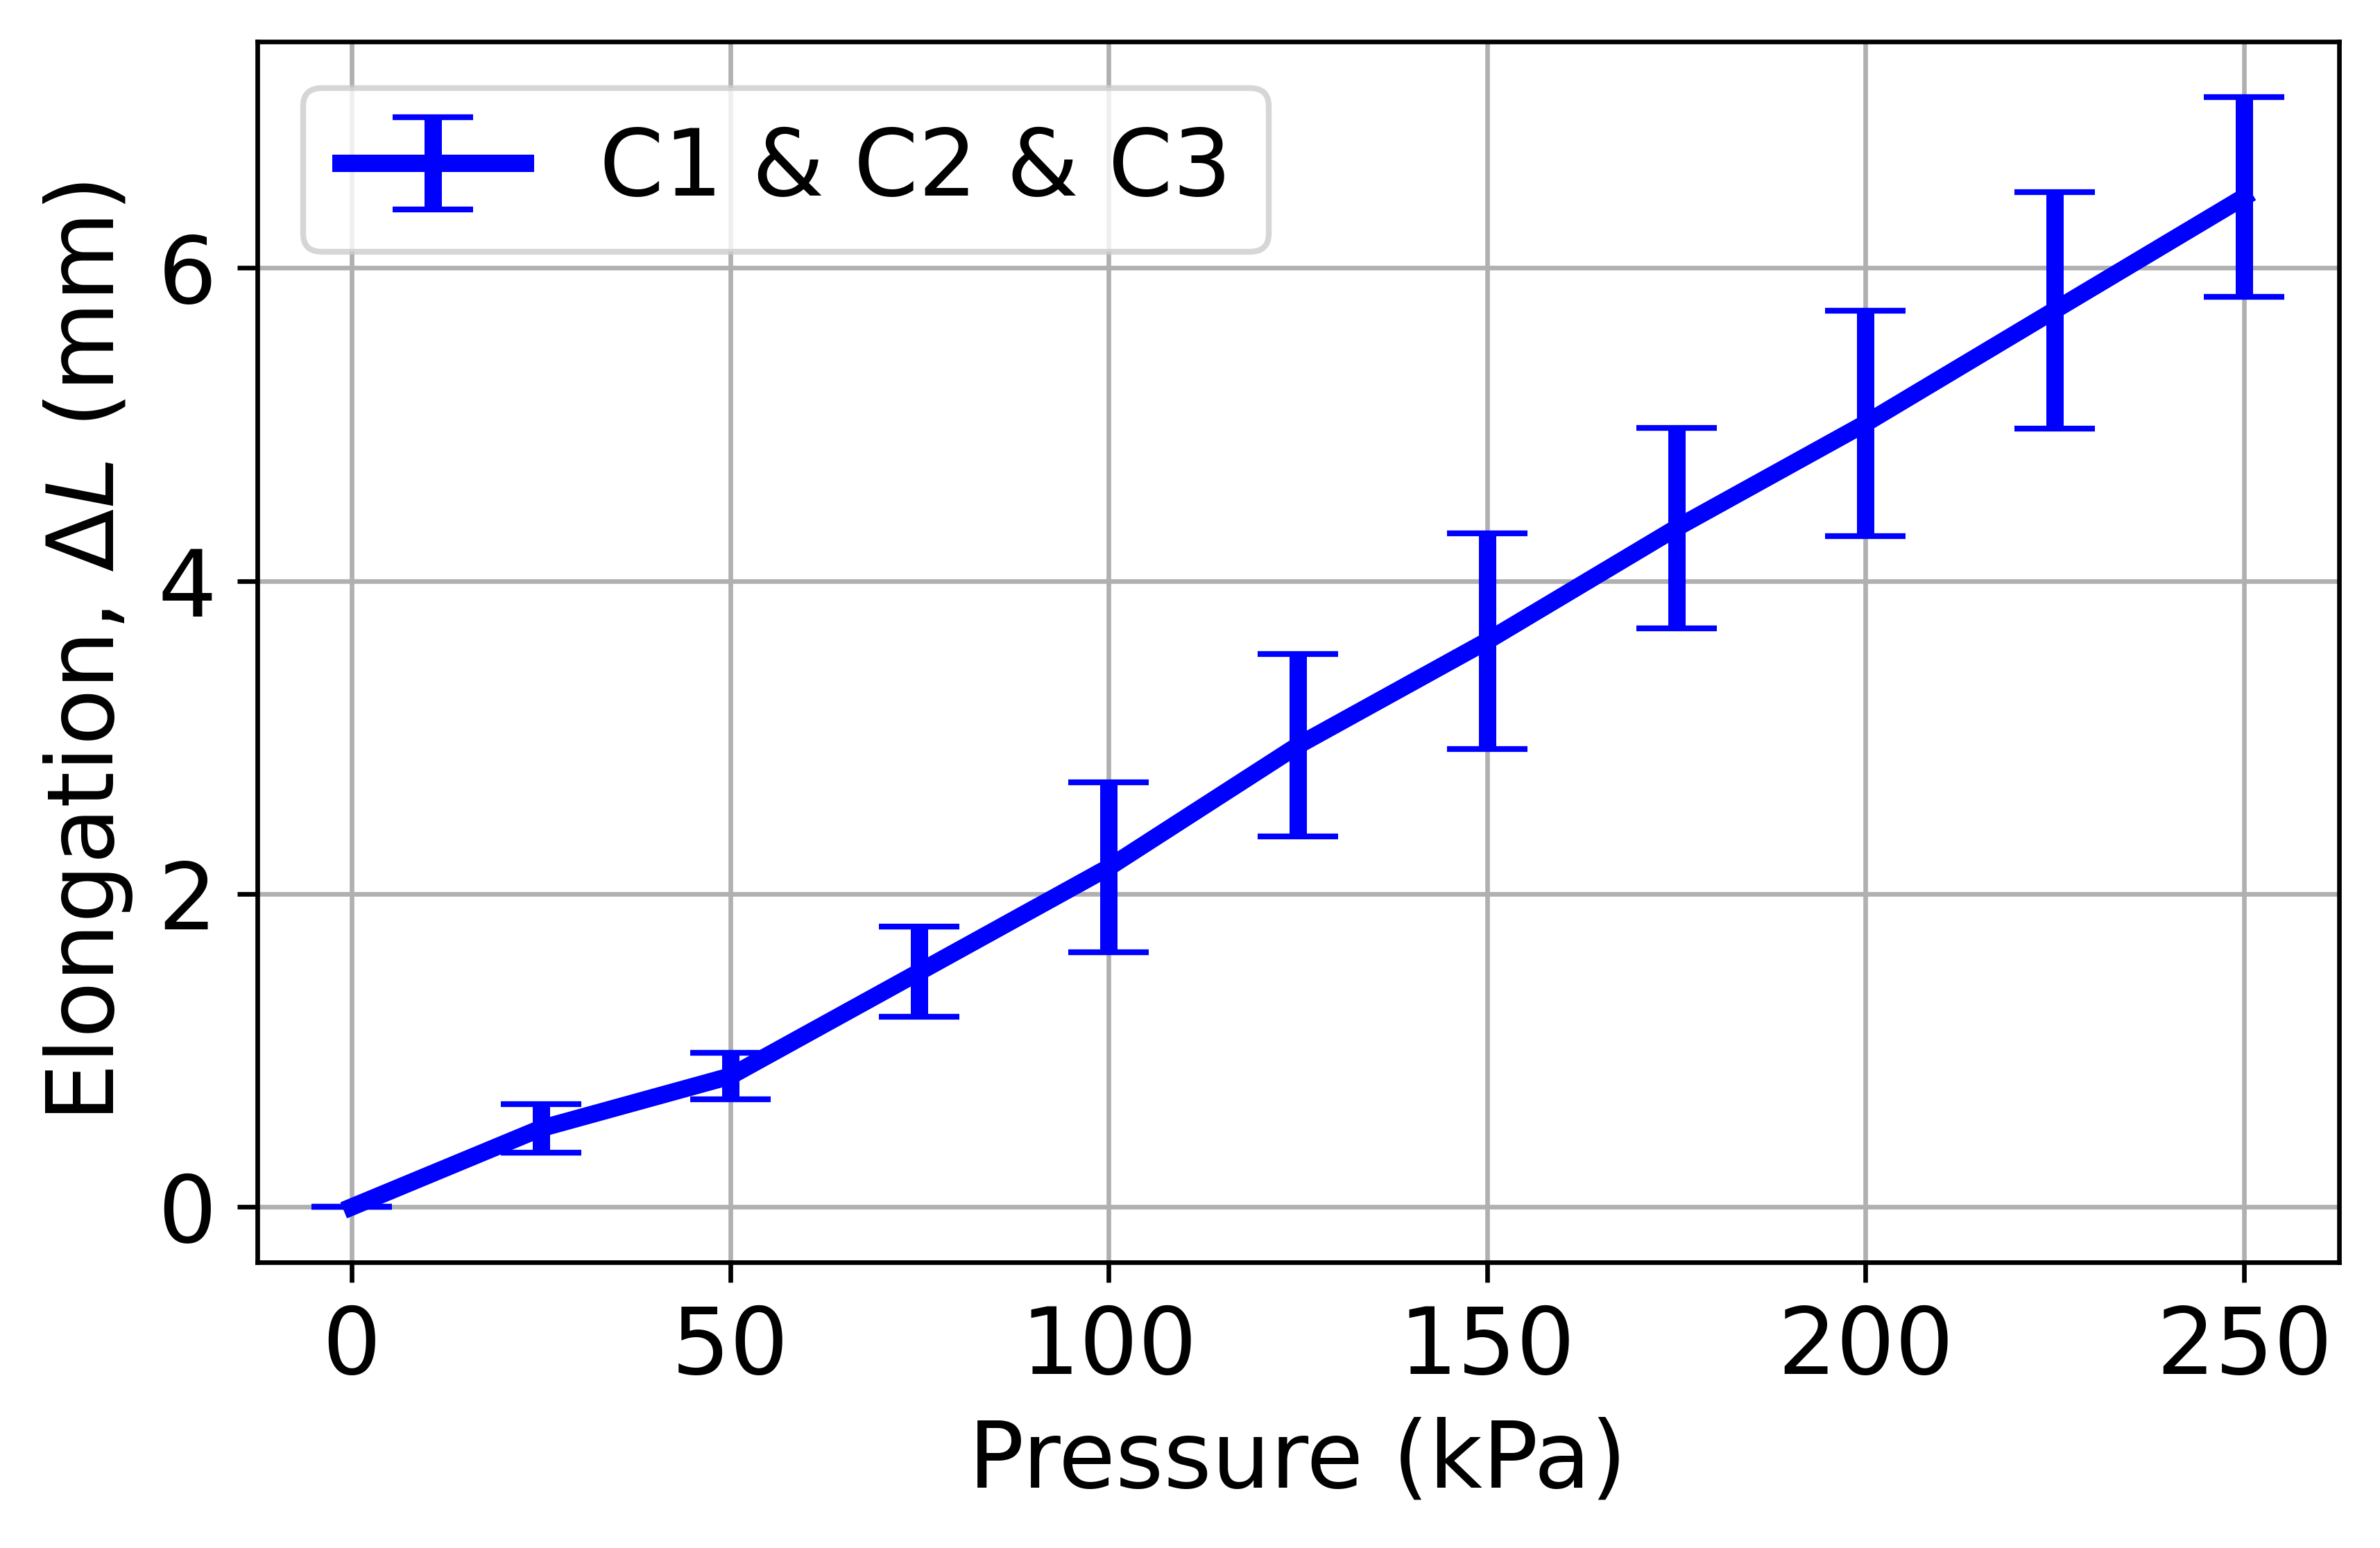

In [12]:
# elongation
fig = plt.figure(figsize=(6,4), dpi=600)
#plt.errorbar(x=pressures, y=delta_ls[:,0], yerr=error_delta_ls[:,0], capsize=7, linewidth=3, label='C1', alpha=0.7)
#plt.errorbar(x=pressures, y=delta_ls[:,1], yerr=error_delta_ls[:,1], capsize=7, linewidth=3, label='C2', alpha=0.7)
#plt.errorbar(x=pressures, y=delta_ls[:,2], yerr=error_delta_ls[:,2], capsize=7, linewidth=3, label='C3', alpha=0.7)
plt.errorbar(x=pressures, y=np.mean(delta_ls, axis=1), yerr=np.mean(error_delta_ls, axis=1), capsize=7, linewidth=3, label='C1 & C2 & C3', color='blue')

plt.xlabel('Pressure (kPa)')
plt.ylabel('Elongation, $\Delta L$ (mm)')

plt.legend(loc='best')
plt.grid()
plt.tight_layout()
fig.savefig('../figures/textile_stiff-flop_elongation.pdf', bbox_inches='tight')
fig.savefig('../figures/textile_stiff-flop_elongation.png', bbox_inches='tight')
fig.savefig('../figures/textile_stiff-flop_elongation.svg', bbox_inches='tight')
plt.show()

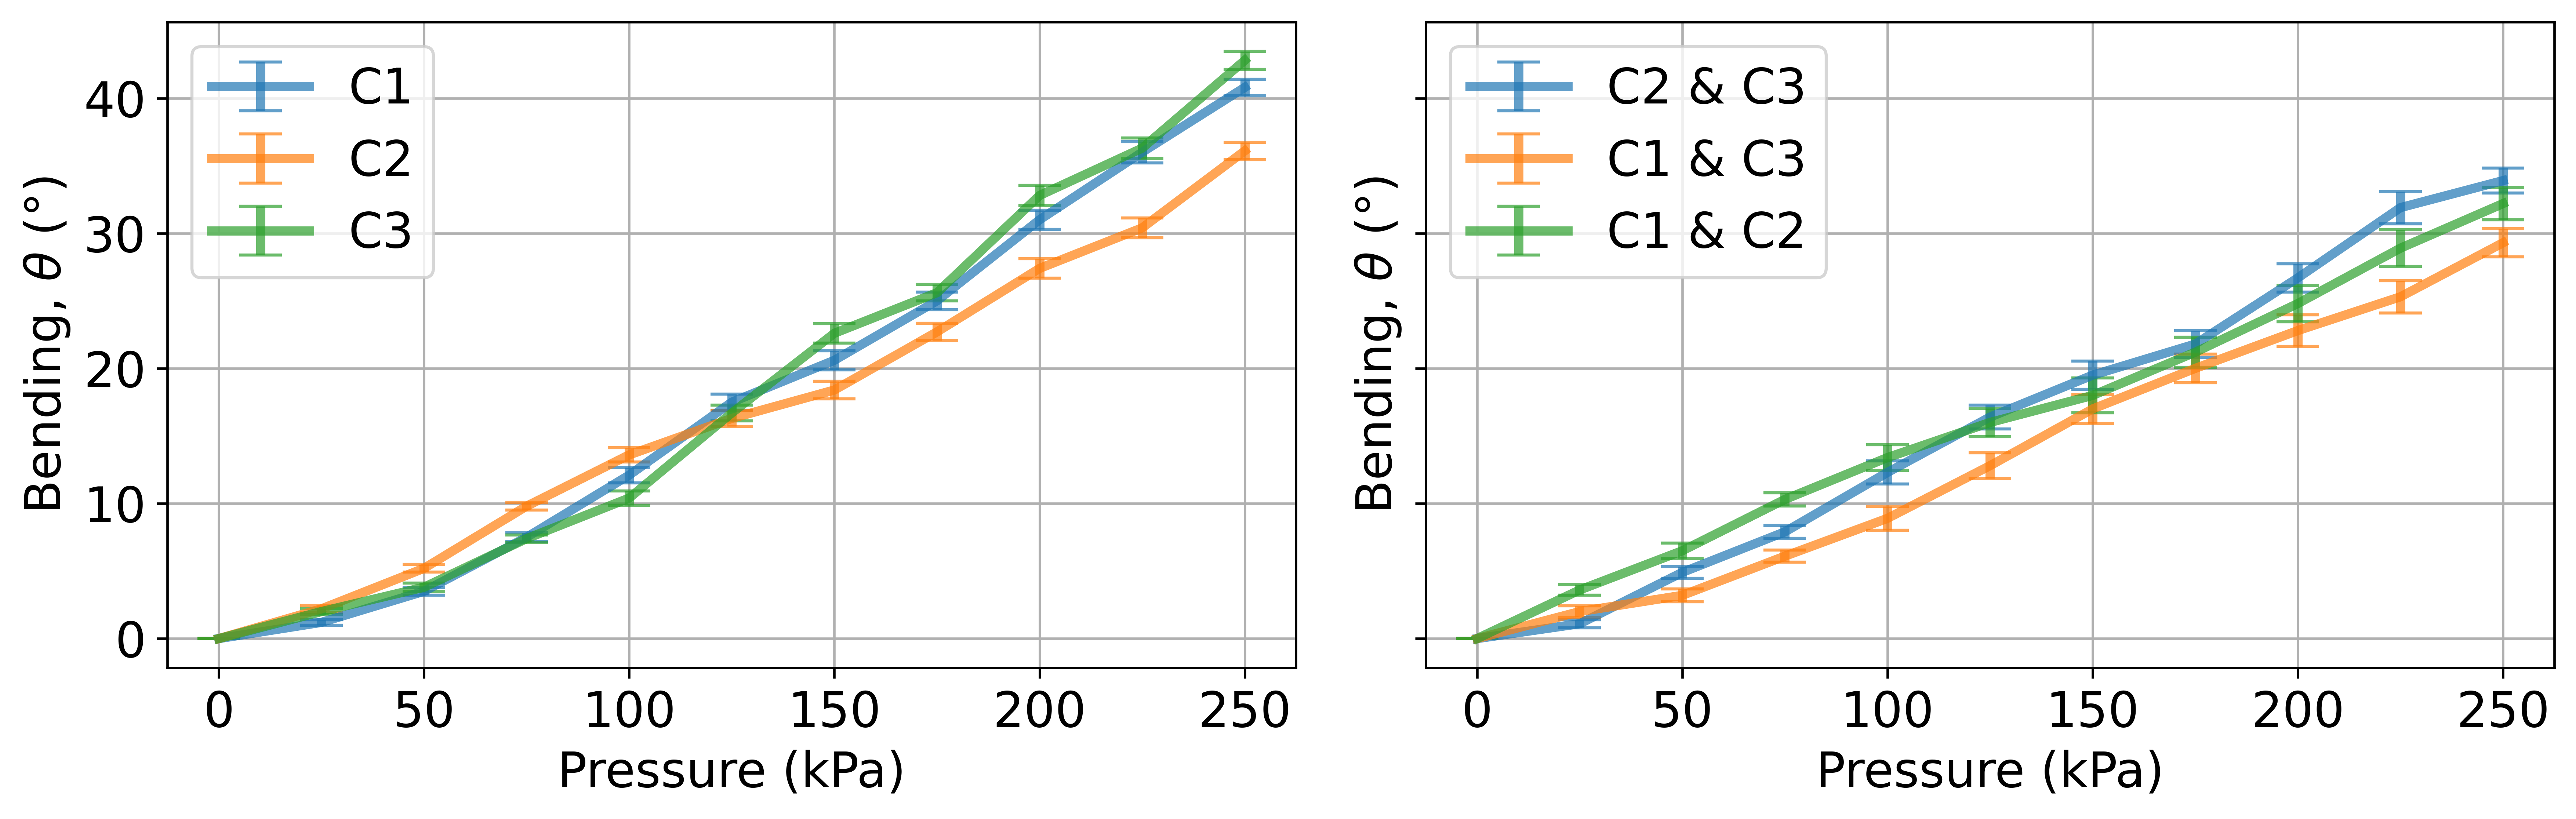

In [11]:
# Bending theta_r e theta_l

# theta_r
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,4), dpi=600, sharey=True)
ax1.errorbar(x=pressures, y=theta_1[:,0], yerr=error_theta_1[:,0], capsize=7, linewidth=3, label='C1', alpha=0.7)
ax1.errorbar(x=pressures, y=theta_1[:,1], yerr=error_theta_1[:,1], capsize=7, linewidth=3, label='C2', alpha=0.7)
ax1.errorbar(x=pressures, y=theta_1[:,2], yerr=error_theta_1[:,2], capsize=7, linewidth=3, label='C3', alpha=0.7)
ax1.set_xlabel('Pressure (kPa)')
ax1.set_ylabel(r'Bending, $\theta$ ($\degree$)')
ax1.grid()

ax2.errorbar(x=pressures, y=theta_2[:,0], yerr=error_theta_2[:,0], capsize=7, linewidth=3, label='C2 & C3', alpha=0.7)
ax2.errorbar(x=pressures, y=theta_2[:,1], yerr=error_theta_2[:,1], capsize=7, linewidth=3, label='C1 & C3', alpha=0.7)
ax2.errorbar(x=pressures, y=theta_2[:,2], yerr=error_theta_2[:,2], capsize=7, linewidth=3, label='C1 & C2', alpha=0.7)
ax2.set_xlabel('Pressure (kPa)')
ax2.set_ylabel(r'Bending, $\theta$ ($\degree$)')
ax2.grid()

ax1.legend(loc='best')
ax2.legend(loc='best')
plt.tight_layout()
fig.savefig('../figures/textile_stiff-flop_bending.pdf', bbox_inches='tight')
fig.savefig('../figures/textile_stiff-flop_bending.png', bbox_inches='tight')
fig.savefig('../figures/textile_stiff-flop_bending.svg', bbox_inches='tight')
plt.show()

In [91]:
print("Elongation")
for p, dl, err_dl in zip(pressures, delta_ls, error_delta_ls):
    print('Pressure %d kPa - delta_l (%.1f, %.1f, %.1f) +- (%.1f, %.1f, %.1f) mm' % (p, *dl, *err_dl))

Elongation
Pressure 0 kPa - delta_l (0.0, 0.0, 0.0) +- (0.0, 0.0, 0.0) mm
Pressure 25 kPa - delta_l (0.3, 0.5, 0.7) +- (0.1, 0.2, 0.2) mm
Pressure 50 kPa - delta_l (0.7, 0.7, 1.2) +- (0.2, 0.1, 0.1) mm
Pressure 75 kPa - delta_l (1.3, 1.7, 1.5) +- (0.3, 0.3, 0.3) mm
Pressure 100 kPa - delta_l (2.0, 2.3, 2.2) +- (0.6, 0.5, 0.5) mm
Pressure 125 kPa - delta_l (2.6, 3.0, 3.2) +- (0.6, 0.6, 0.6) mm
Pressure 150 kPa - delta_l (3.3, 3.5, 4.0) +- (0.7, 0.6, 0.7) mm
Pressure 175 kPa - delta_l (4.1, 4.2, 4.7) +- (0.7, 0.6, 0.6) mm
Pressure 200 kPa - delta_l (4.6, 4.9, 5.6) +- (0.7, 0.7, 0.7) mm
Pressure 225 kPa - delta_l (5.3, 5.5, 6.4) +- (0.8, 0.7, 0.8) mm
Pressure 250 kPa - delta_l (6.1, 6.2, 7.1) +- (0.6, 0.6, 0.7) mm


In [92]:
print("\nBending theta_r")
for p, theta_r, err_theta_r in zip(pressures, theta_1, error_theta_1):
    print('Pressure %d kPa - theta_r (%.1f, %.1f, %.1f) +- (%.1f, %.1f, %.1f) deg' % (p, *theta_r, *err_theta_r))


print("\nBending theta_l")
for p, theta_l, err_theta_l in zip(pressures, theta_2, error_theta_2):
    print('Pressure %d kPa - theta_l (%.1f, %.1f, %.1f) +- (%.1f, %.1f, %.1f) deg' % (p, *theta_l, *err_theta_l))


Bending theta_r
Pressure 0 kPa - theta_r (0.0, 0.0, 0.0) +- (0.0, 0.0, 0.0) deg
Pressure 25 kPa - theta_r (1.2, 2.2, 2.0) +- (0.2, 0.3, 0.2) deg
Pressure 50 kPa - theta_r (3.5, 5.2, 3.8) +- (0.3, 0.3, 0.3) deg
Pressure 75 kPa - theta_r (7.5, 9.8, 7.4) +- (0.3, 0.3, 0.3) deg
Pressure 100 kPa - theta_r (12.1, 13.6, 10.4) +- (0.6, 0.5, 0.5) deg
Pressure 125 kPa - theta_r (17.5, 16.3, 16.7) +- (0.6, 0.6, 0.6) deg
Pressure 150 kPa - theta_r (20.6, 18.4, 22.6) +- (0.7, 0.6, 0.7) deg
Pressure 175 kPa - theta_r (25.0, 22.7, 25.6) +- (0.7, 0.6, 0.6) deg
Pressure 200 kPa - theta_r (31.0, 27.4, 32.8) +- (0.7, 0.7, 0.7) deg
Pressure 225 kPa - theta_r (36.0, 30.4, 36.3) +- (0.8, 0.7, 0.8) deg
Pressure 250 kPa - theta_r (40.8, 36.1, 42.8) +- (0.6, 0.6, 0.7) deg

Bending theta_l
Pressure 0 kPa - theta_l (0.0, 0.0, 0.0) +- (0.0, 0.0, 0.0) deg
Pressure 25 kPa - theta_l (1.1, 2.0, 3.6) +- (0.3, 0.4, 0.4) deg
Pressure 50 kPa - theta_l (4.9, 3.2, 6.5) +- (0.4, 0.5, 0.6) deg
Pressure 75 kPa - theta_l (7.9

In [16]:
# save arrays for nicco
np.savez(file="./soft-tex-push-pull-deltal.npz",
         pressures=pressures, 
         mean_push_forces=mean_push_forces, 
         std_push_forces=std_push_forces, 
         mean_pull_forces=mean_pull_forces, 
         std_pull_forces=std_pull_forces,
         delta_l_mean=np.mean(delta_ls, axis=1), 
         delta_l_std=np.mean(error_delta_ls, axis=1)
        )

results = np.load("soft-tex-push-pull.npz")
results['mean_push_forces'], results['delta_l_mean'], results['delta_l_std']

(array([3.3984   , 5.184467 , 6.5686665, 7.4158998], dtype=float32),
 array([0.        , 0.502     , 0.83566667, 1.50233333, 2.16966667,
        2.949     , 3.61666667, 4.339     , 5.00766667, 5.731     ,
        6.45333333]),
 array([0.        , 0.15673333, 0.1488    , 0.28776667, 0.54376667,
        0.58266667, 0.6899    , 0.64073333, 0.72093333, 0.7554    ,
        0.6388    ]))

In [ ]:
# check sequence length increments
for i in range(120):

    sequence_len = 20 + 10 * int(i / 20) # curriculum 3.4
    sequence_len = min(sequence_len, 50)
    print(i, sequence_len)

0 20
1 20
2 20
3 20
4 20
5 20
6 20
7 20
8 20
9 20
10 20
11 20
12 20
13 20
14 20
15 20
16 20
17 20
18 20
19 20
20 30
21 30
22 30
23 30
24 30
25 30
26 30
27 30
28 30
29 30
30 30
31 30
32 30
33 30
34 30
35 30
36 30
37 30
38 30
39 30
40 40
41 40
42 40
43 40
44 40
45 40
46 40
47 40
48 40
49 40
50 40
51 40
52 40
53 40
54 40
55 40
56 40
57 40
58 40
59 40
60 50
61 50
62 50
63 50
64 50
65 50
66 50
67 50
68 50
69 50
70 50
71 50
72 50
73 50
74 50
75 50
76 50
77 50
78 50
79 50
80 50
81 50
82 50
83 50
84 50
85 50
86 50
87 50
88 50
89 50
90 50
91 50
92 50
93 50
94 50
95 50
96 50
97 50
98 50
99 50
100 50
101 50
102 50
103 50
104 50
105 50
106 50
107 50
108 50
109 50
110 50
111 50
112 50
113 50
114 50
115 50
116 50
117 50
118 50
119 50
